# Mini Projet  :Classification des chats et des chiens à l'aide d'un réseau neuronal convolutif

1. Importation des bibliothèques

In [ ]:
#Importaion des Bibliothèques

#--------------------------------------------------------------------------------------------------------
#Bibliothèques générales
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
#--------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------
#Bibliothèques Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D , Dropout
#--------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------
# Bibliothèques de Gestion des images
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory
#--------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.image as mpimg
#--------------------------------------------------------------------------------------------------------


2. Importation du jeu de données

Nous utiliserons le jeu de données Kaggle, qui se présente sous la forme d'un fichier zip contenant deux dossiers : « Cat » et « Dog ». Chaque dossier contient 12 500 images de l'animal correspondant. Pour importer et décompresser le fichier, nous pouvons exécuter le code ci-dessous.


*   Le module ZipFile extrait les fichiers de données de l'archive zip.
*   Les données extraites sont stockées dans le dossier « dog-vs-cat-classification ».



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/dog-vs-cat.zip'


In [ ]:
from zipfile import ZipFile
import os # Import os for path checks

data_path = dataset_path

if os.path.isdir(data_path):
    print(f"Error: The path '{data_path}' is a directory, but ZipFile expects a file.")
    print("Please ensure that 'dog-vs-cat.zip' is an actual zip file and not a directory in your Google Drive.")
elif not os.path.exists(data_path):
    print(f"Error: The file '{data_path}' does not exist.")
    print("Please ensure the 'dog-vs-cat.zip' file is present in your Google Drive at the specified path.")
else:
    try:
        with ZipFile(data_path, 'r') as zip_ref: # Renamed 'zip' to 'zip_ref' to avoid conflict with imported ZipFile
            zip_ref.extractall()
            print('The data set has been extracted.')
    except Exception as e:
        print(f"An error occurred while extracting the zip file: {e}")
        print("Please check if the file is a valid zip archive.")

Error: The path '/content/drive/MyDrive/dog-vs-cat.zip' is a directory, but ZipFile expects a file.
Please ensure that 'dog-vs-cat.zip' is an actual zip file and not a directory in your Google Drive.


3. Visualisation des données

Reorganizing images in: /content/drive/MyDrive/dog-vs-cat.zip
Image reorganization complete. Images are now in 'Cat' and 'Dog' subfolders.


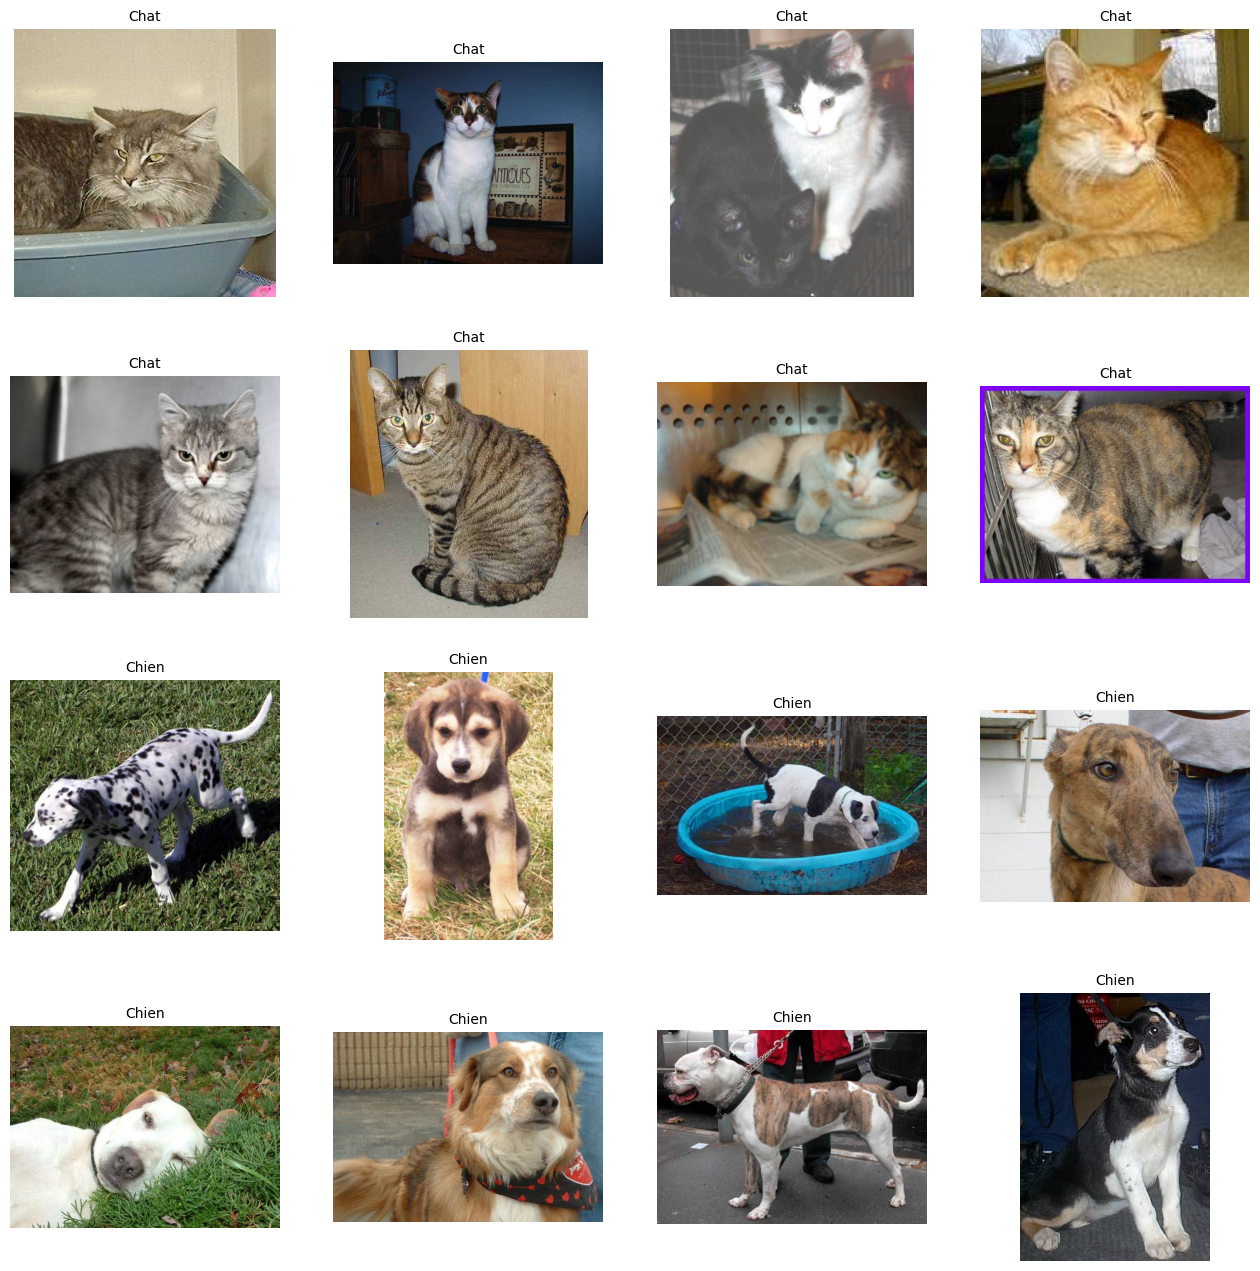

In [ ]:
import os
import shutil

# Le dossier où se trouvent toutes vos images
base_dir = dataset_path # /content/drive/MyDrive/dog-vs-cat.zip

# Chemins pour les nouveaux sous-dossiers
cat_dir = os.path.join(base_dir, 'Cat')
dog_dir = os.path.join(base_dir, 'Dog')

# Créer les sous-dossiers s'ils n'existent pas
os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

# Parcourir tous les fichiers dans le dossier de base
print(f"Reorganizing images in: {base_dir}")
for img_name in os.listdir(base_dir):
    if img_name.lower().startswith('cat') and img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        current_path = os.path.join(base_dir, img_name)
        destination_path = os.path.join(cat_dir, img_name)
        if os.path.exists(current_path) and not os.path.exists(destination_path):
            shutil.move(current_path, destination_path)
    elif img_name.lower().startswith('dog') and img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        current_path = os.path.join(base_dir, img_name)
        destination_path = os.path.join(dog_dir, img_name)
        if os.path.exists(current_path) and not os.path.exists(destination_path):
            shutil.move(current_path, destination_path)

print("Image reorganization complete. Images are now in 'Cat' and 'Dog' subfolders.")

# --- Code for Visualization (unchanged from previous step, but placed after reorganization) ---
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Taille de la figure
plt.figure(figsize=(16, 16))

# Update base_dir to point to the parent directory of Cat/Dog for visualization (if needed)
# For visualization, we can now access the images from the newly created cat_dir and dog_dir

# Récupération des images à partir des nouveaux sous-dossiers
cat_images = os.listdir(cat_dir)
dog_images = os.listdir(dog_dir)

if not cat_images:
    print(f"Error: No cat images found in {cat_dir}")
    print("Please ensure image files starting with 'cat' (e.g., cat.1.jpg) were moved to this folder.")
elif not dog_images:
    print(f"Error: No dog images found in {dog_dir}")
    print("Please ensure image files starting with 'dog' (e.g., dog.1.jpg) were moved to this folder.")
else:
    # Mélange aléatoire
    random.shuffle(cat_images)
    random.shuffle(dog_images)

    # Nombre d'images à afficher par classe
    n_images = 8

    cat_images = cat_images[:n_images]
    dog_images = dog_images[:n_images]

    # Affichage
    for i, img_name in enumerate(cat_images + dog_images):
        plt.subplot(4, 4, i + 1)
        plt.axis('off')

        if i < n_images:
            img_path = os.path.join(cat_dir, img_name)
            plt.title("Chat", fontsize=10)
        else:
            img_path = os.path.join(dog_dir, img_name)
            plt.title("Chien", fontsize=10)

        try:
            img = mpimg.imread(img_path)
            plt.imshow(img)
        except Exception as e:
            print(f"Could not load image {img_name}: {e}")
            plt.text(0.5, 0.5, "Image non valide",
                     ha='center', va='center')


4. Division de l'ensemble de données

Nous avons divisé l'ensemble de données en ensembles d'entraînement et de validation.


*   image_dataset_from_directory : est utilisé pour l’augmentation des données et la mise à l’échelle des images.

*   L'ensemble de données est divisé en 90 % pour l'entraînement et 10 % pour la validation.
*   target_size=(200, 200): Redimensionne les images à 200x200 pixels.


*   batch_size=32 : Définit le nombre d’images par lot.



In [ ]:
#base_dir = 'dog-vs-cat-classification'

train_data = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='training',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)
test_data = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='validation',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)

Found 25000 files belonging to 2 classes.
Using 22500 files for training.
Found 25000 files belonging to 2 classes.
Using 2500 files for validation.


5. Architecture du modèle

Les étapes de models :



*   Couches Conv2D : extraient les caractéristiques de l’image telles que les contours, les formes et les textures.

*   MaxPooling2D : réduit les dimensions de l’image tout en conservant les informations importantes.
*   Élément de liste


*   Normalisation par lots : contribue à stabiliser l’entraînement et à accélérer la convergence



*   Couches de suppression : empêchent le surapprentissage.
*   Activation sigmoïde : produit une classification binaire comme Chat ou Chien.





In [ ]:
model = tf.keras.models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200,3)) ,
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')

])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

6. Compilation et formation du modèle

Nous allons maintenant compiler et entraîner notre modèle. Nous avons utilisé la fonction de perte d'entropie croisée binaire pour les problèmes de classification binaire avec l'optimiseur Adam.

In [ ]:

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(train_data,
          epochs=10,
          validation_data=test_data)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3831s 5s/step - accuracy: 0.5956 - loss: 0.7381 - val_accuracy: 0.7300 - val_loss: 0.5579
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1820s 3s/step - accuracy: 0.7417 - loss: 0.5205 - val_accuracy: 0.5804 - val_loss: 0.6791
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1797s 3s/step - accuracy: 0.7903 - loss: 0.4535 - val_accuracy: 0.8288 - val_loss: 0.3956
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1820s 3s/step - accuracy: 0.8445 - loss: 0.3562 - val_accuracy: 0.5304 - val_loss: 1.5996
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1857s 3s/step - accuracy: 0.6460 - loss: 0.6393 - val_accuracy: 0.7104 - val_loss: 0.5660
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1803s 3s/step - accuracy: 0.7488 - loss: 0.5079 - val_accuracy: 0.6832 - val_loss: 0.7390
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1862s 3s/step - accuracy: 0.7940 - loss: 0.4437 - val_accuracy: 0.5252 - val_loss: 1.0549
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1838s 3s/step - accuracy: 0.7687 - loss: 0.4851 - 

7. Évaluation du modèle

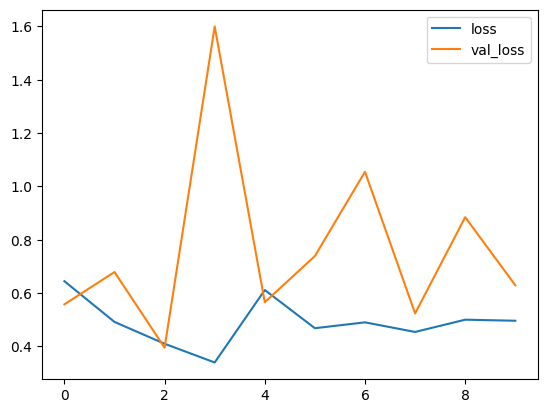

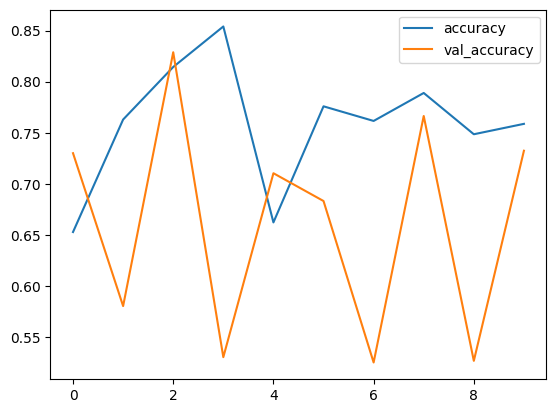

In [ ]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

8. Tests et prédiction du modèle

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Dog


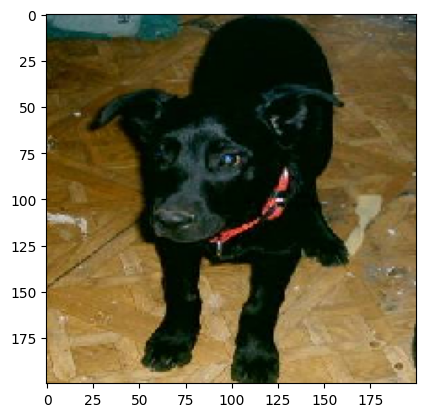

In [ ]:
from tensorflow.keras.preprocessing import image
import os # Ensure os module is imported for path manipulation

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    plt.imshow(img)
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    result = model.predict(img)
    print("Dog" if result >= 0.5 else "Cat")

# Correcting the paths to reflect the actual location of images
# The variables cat_dir and dog_dir were set correctly in a previous cell
predict_image(os.path.join(cat_dir, 'cat.320.jpg'))
predict_image(os.path.join(dog_dir, 'dog.5510.jpg'))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Cat


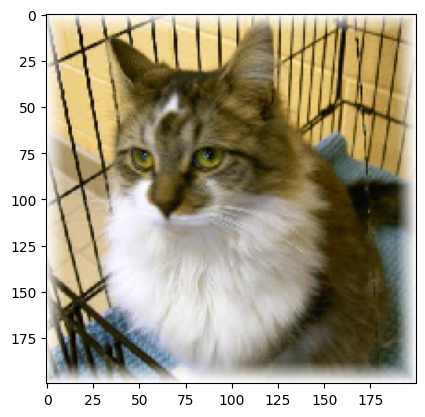

In [ ]:
predict_image(os.path.join(cat_dir, 'cat.320.jpg'))